# Notebook 05 - Business Impact & Case File Triage

**Project:** Provider Aberrant Billing Pattern Detection (P3)  
**Upstream:** NB04 (cross-method validation, audit tiers)  
**Downstream:** README, Medium post, portfolio presentation

---

## Purpose

This notebook translates analytical outputs into operational deliverables:

1. **Business impact quantification** - excess billing exposure by tier, specialty, and volume band, framed in the language of SIU resource allocation.
2. **Case file generation** - structured, one-page investigation briefs for the highest-confidence (Tier 1) providers, ready for an SIU analyst.
3. **Methodology limitations & caveats** - an explicit, honest statement of what this analysis can and cannot claim, given the synthetic nature of DE-SynPUF.

### A note on scope

This project deliberately implements the same analytical pipeline across Snowflake (SQL), SAS, and Python/DuckDB. In a production setting, a single technology stack would be selected based on organizational infrastructure, licensing, and team expertise. The multi-stack approach here demonstrates proficiency across the technologies commonly used in healthcare operations.

**The methods transfer to real claims data. The specific dollar estimates and provider flags do not!**<br>
DE-SynPUF was synthesized by CMS with noise injection, distribution truncation, and scrambled linkages. The extreme tails where aberrant billing lives are the most distorted region of the dataset. The framework (peer-group z-scores → Isolation Forest → two-gate concordance → tiered triage) is production-grade. The numbers populated by synthetic data are proof-of-concept.


In [ ]:
import sys
import warnings
import numpy as np
import pandas as pd
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

from pathlib import Path
_cwd = Path.cwd()
if (_cwd / 'src').is_dir():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / 'src').is_dir():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = Path('YOUR FOLDER')
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    FIGURES_DIR, OUTPUT_DIR, CASE_FILES_DIR,
    Z_THRESHOLD_PRIMARY, Z_THRESHOLD_SEVERE,
    DATA_SOURCE_CITATION, TECH_DISCLAIMER,
    COMPOSITE_WEIGHTS, PRIORITY_THRESHOLDS,
)
from src.visual_identity import *

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CASE_FILES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Visual identity loaded. Serif: {SERIF} | Sans: {SANS}")
print(f"Case files location: {CASE_FILES_DIR.relative_to(PROJECT_ROOT)}")

Visual identity loaded. Serif: Liberation Serif | Sans: Liberation Sans
Case files location: .


## 1. Load NB04 export


In [28]:
# =============================================================================
# Load tiered provider matrix from NB04
# =============================================================================

input_path = OUTPUT_DIR / 'nb04_providers_with_audit_tiers.csv'
df = pd.read_csv(input_path)

print(f"Loaded: {len(df):,} providers × {len(df.columns)} columns")
print(f"Source: {input_path.name}")
print()

# Tier counts
tier_order = ['Tier 1 - High confidence', 'Tier 2 - IF multivariate',
              'Tier 3 - Z-score statistical', 'Unflagged']
print("Audit tier distribution:")
print("=" * 60)
for tier in tier_order:
    n = (df['audit_tier'] == tier).sum()
    print(f"  {tier:35s} {n:>8,} ({n/len(df)*100:.2f}%)")

# Flag providers with positive excess billing
has_excess = 'excess_billing' in df.columns
if has_excess:
    df['excess_positive'] = df['excess_billing'].clip(lower=0)
    print(f"\nProviders with positive excess billing: {(df['excess_positive'] > 0).sum():,}")
    print(f"Total excess billing (all tiers):       ${df.loc[df['audit_tier'] != 'Unflagged', 'excess_positive'].sum():,.0f}")


Loaded: 477,589 providers × 33 columns
Source: nb04_providers_with_audit_tiers.csv

Audit tier distribution:
  Tier 1 - High confidence              18,424 (3.86%)
  Tier 2 - IF multivariate               5,456 (1.14%)
  Tier 3 - Z-score statistical          16,498 (3.45%)
  Unflagged                            437,211 (91.55%)

Providers with positive excess billing: 241,267
Total excess billing (all tiers):       $31,615,341


## 2. Business impact quantification

### Framing for SIU resource allocation

In production FWA operations, the SIU has finite investigator capacity (heads and budget). The value of a triage system is not the total dollar exposure it identifies, it's the **yield per investigation**. A system that sends 100 high-quality leads is more valuable than one that sends 10,000 noisy flags.

We quantify impact along three axes:
- **Tier-level exposure** - total and per-provider excess billing by audit tier
- **Specialty concentration** - which clinical categories concentrate the exposure
- **Volume bands** - small vs. large providers within each tier

> **Caveat:** All dollar figures in this section are derived from DE-SynPUF synthetic data. They demonstrate the framework's ability to stratify and quantify exposure, but the specific amounts do not represent real Medicare billing patterns.


In [29]:
# =============================================================================
# 2.1 - Excess billing by tier: summary statistics
# =============================================================================

if has_excess:
    tier_impact = []
    for tier in tier_order[:-1]:  # Exclude Unflagged
        subset = df[(df['audit_tier'] == tier) & (df['excess_positive'] > 0)]
        tier_impact.append({
            'Audit tier': tier.split(' - ')[0],
            'Providers': len(subset),
            'Total excess ($)': subset['excess_positive'].sum(),
            'Mean excess ($)': subset['excess_positive'].mean() if len(subset) > 0 else 0,
            'Median excess ($)': subset['excess_positive'].median() if len(subset) > 0 else 0,
            'P90 excess ($)': subset['excess_positive'].quantile(0.90) if len(subset) > 0 else 0,
            'Max excess ($)': subset['excess_positive'].max() if len(subset) > 0 else 0,
        })

    df_impact = pd.DataFrame(tier_impact)

    render_table(
        df_impact,
        title='Excess billing exposure by audit tier',
        fmt={
            'Total excess ($)': '${:,.0f}',
            'Mean excess ($)': '${:,.0f}',
            'Median excess ($)': '${:,.0f}',
            'P90 excess ($)': '${:,.0f}',
            'Max excess ($)': '${:,.0f}',
            'Providers': '{:,}',
        }
    )

    # Yield per investigation
    for row in tier_impact:
        if row['Providers'] > 0:
            print(f"  {row['Audit tier']}: ${row['Mean excess ($)']:,.0f} avg exposure per investigation")
else:
    print("Excess billing column not found. Skipping impact quantification.")
    print("This column is computed in NB03 - re-run if needed.")


Audit tier,Providers,Total excess ($),Mean excess ($),Median excess ($),P90 excess ($),Max excess ($)
Tier 1,"8,676","$17,040,354","$1,964","$1,110","$3,915","$239,570"
Tier 2,"2,477","$5,776,506","$2,332","$1,064","$4,134","$237,523"
Tier 3,"8,298","$8,798,482","$1,060",$870,"$2,229","$12,937"


  Tier 1: $1,964 avg exposure per investigation
  Tier 2: $2,332 avg exposure per investigation
  Tier 3: $1,060 avg exposure per investigation


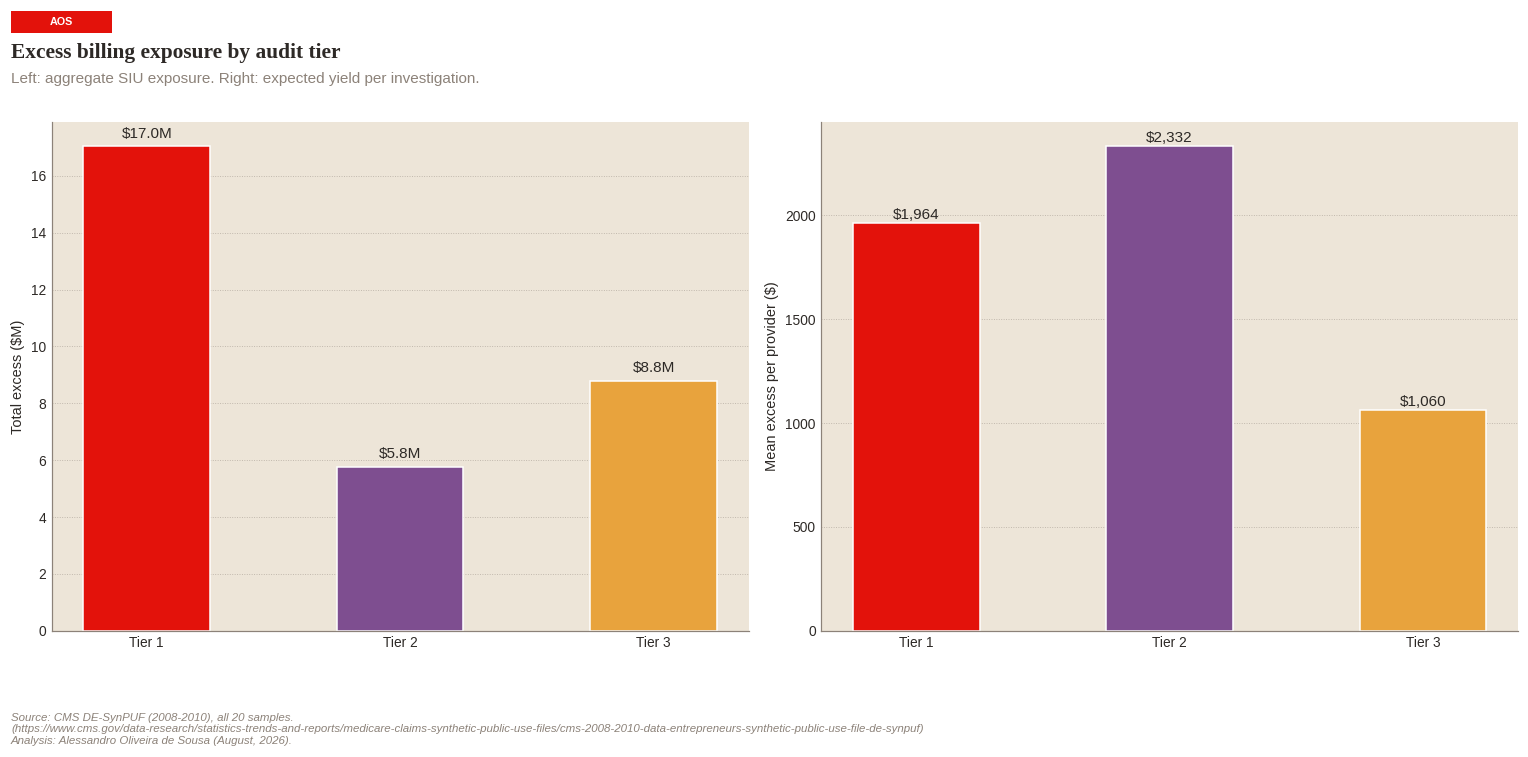

In [30]:
# =============================================================================
# 2.2 - Excess billing by tier: bar chart
# =============================================================================

if has_excess:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    tier_labels = [r['Audit tier'] for r in tier_impact]
    tier_colors = [ECON_RED, PLUM, AMBER]

    # Left: total exposure
    bars = axes[0].bar(tier_labels,
                       [r['Total excess ($)'] / 1e6 for r in tier_impact],
                       color=tier_colors, edgecolor='white', width=0.5)
    for bar, row in zip(bars, tier_impact):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'${row["Total excess ($)"]/1e6:.1f}M',
                     ha='center', fontsize=10, color=CHARCOAL)
    adjust_axis(axes[0], ylabel='Total excess ($M)')

    # Right: mean per provider
    bars2 = axes[1].bar(tier_labels,
                        [r['Mean excess ($)'] for r in tier_impact],
                        color=tier_colors, edgecolor='white', width=0.5)
    for bar, row in zip(bars2, tier_impact):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                     f'${row["Mean excess ($)"]:,.0f}',
                     ha='center', fontsize=10, color=CHARCOAL)
    adjust_axis(axes[1], ylabel='Mean excess per provider ($)')

    fig_title(fig,
              title='Excess billing exposure by audit tier',
              subtitle='Left: aggregate SIU exposure. Right: expected yield per investigation.',
              top=0.9,)
    visual_identity(fig)
    plt.savefig(FIGURES_DIR / 'nb05_excess_by_tier_dual.png')
    plt.show()


derived_specialty,providers,total_excess,mean_excess,tier1_count,pct_of_total,pct_tier1
Evaluation & Management,"35,721","$29,561,259",$828,"16,439",93.5%,46.0%
Surgery,"2,967","$1,371,350",$462,"1,377",4.3%,46.4%
Medicine,646,"$285,615",$442,238,0.9%,36.8%
Pathology & Lab,730,"$233,895",$320,262,0.7%,35.9%
Radiology,140,"$76,300",$545,40,0.2%,28.6%
HCPCS Level II,80,"$46,968",$587,33,0.1%,41.2%
Other,94,"$39,952",$425,35,0.1%,37.2%


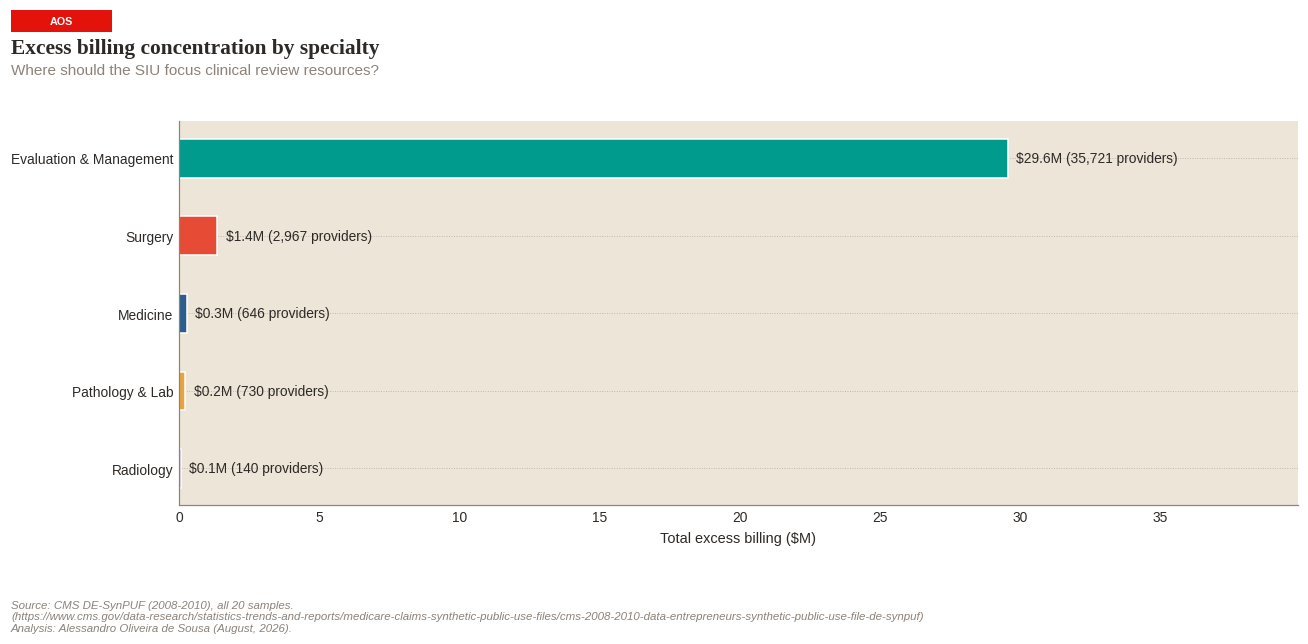

In [31]:
# =============================================================================
# 2.3 - Specialty concentration of excess billing
# =============================================================================

if has_excess and 'derived_specialty' in df.columns:
    flagged = df[df['audit_tier'] != 'Unflagged'].copy()

    spec_exposure = (
        flagged.groupby('derived_specialty')
        .agg(
            providers=('provider_npi', 'count'),
            total_excess=('excess_positive', 'sum'),
            mean_excess=('excess_positive', 'mean'),
            tier1_count=('audit_tier', lambda x: (x == 'Tier 1 - High confidence').sum()),
        )
        .sort_values('total_excess', ascending=False)
    )
    spec_exposure['pct_of_total'] = spec_exposure['total_excess'] / spec_exposure['total_excess'].sum() * 100
    spec_exposure['pct_tier1'] = spec_exposure['tier1_count'] / spec_exposure['providers'] * 100

    render_table(
        spec_exposure.reset_index().head(10),
        title='Top 10 specialties by excess billing exposure (flagged providers)',
        fmt={
            'total_excess': '${:,.0f}',
            'mean_excess': '${:,.0f}',
            'providers': '{:,}',
            'tier1_count': '{:,}',
            'pct_of_total': '{:.1f}%',
            'pct_tier1': '{:.1f}%',
        }
    )

    # Bar chart: top specialties
    top5 = spec_exposure.head(5)
    fig, ax = plt.subplots(figsize=(12, 5))
    vals = top5['total_excess'] / 1e6
    bars = ax.barh(range(len(top5)), vals,
                   color=PALETA_SEQ[:len(top5)], edgecolor='white', height=0.5)
    ax.set_yticks(range(len(top5)))
    ax.set_yticklabels([truncar(s, 25) for s in top5.index], fontsize=10)
    ax.invert_yaxis()

    # Pad x-axis: 35% extra headroom for labels
    x_max = vals.max()
    ax.set_xlim(0, x_max * 1.35)

    for bar, (_, row) in zip(bars, top5.iterrows()):
        label = f'${row["total_excess"]/1e6:.1f}M ({row["providers"]:,.0f} providers)'
        ax.text(bar.get_width() + x_max * 0.01, bar.get_y() + bar.get_height()/2,
                label, va='center', fontsize=9, color=CHARCOAL)

    adjust_axis(ax, xlabel='Total excess billing ($M)')
    fig_title(fig,
              title='Excess billing concentration by specialty',
              subtitle='Where should the SIU focus clinical review resources?',
              top=0.88)
    visual_identity(fig)
    plt.savefig(FIGURES_DIR / 'nb05_excess_by_specialty.png')
    plt.show()


In [32]:
# =============================================================================
# 2.4 - Volume bands: are the flags concentrated in high-volume providers?
# =============================================================================

if 'total_lines' in df.columns:
    flagged = df[df['audit_tier'] != 'Unflagged'].copy()

    # Define volume bands
    bins = [0, 100, 500, 2000, 10000, np.inf]
    labels = ['30-100', '101-500', '501-2K', '2K-10K', '10K+']
    flagged['volume_band'] = pd.cut(flagged['total_lines'], bins=bins, labels=labels)

    vol_summary = (
        flagged.groupby('volume_band', observed=False)
        .agg(
            providers=('provider_npi', 'count'),
            total_excess=('excess_positive', 'sum') if has_excess else ('total_lines', 'sum'),
            tier1=('audit_tier', lambda x: (x == 'Tier 1 - High confidence').sum()),
        )
    )
    vol_summary['pct_providers'] = vol_summary['providers'] / vol_summary['providers'].sum() * 100

    fmt_dict = {'providers': '{:,}', 'tier1': '{:,}', 'pct_providers': '{:.1f}%'}
    if has_excess:
        fmt_dict['total_excess'] = '${:,.0f}'

    render_table(
        vol_summary.reset_index(),
        title='Flagged providers by volume band',
        fmt=fmt_dict
    )

    print("\nInterpretation:")
    largest_band = vol_summary['providers'].idxmax()
    print(f"  Most flagged providers are in the '{largest_band}' band.")
    if has_excess:
        richest_band = vol_summary['total_excess'].idxmax()
        print(f"  Highest excess billing concentration: '{richest_band}' band.")
        print(f"  High-volume providers may warrant priority investigation")
        print(f"  due to larger per-provider exposure.")


volume_band,providers,total_excess,tier1,pct_providers
30-100,"23,141","$9,691,682","8,988",57.3%
101-500,"10,314","$6,669,840","3,995",25.5%
501-2K,"5,655","$7,688,783","4,397",14.0%
2K-10K,"1,036","$2,685,171",851,2.6%
10K+,232,"$4,879,865",193,0.6%



Interpretation:
  Most flagged providers are in the '30-100' band.
  Highest excess billing concentration: '30-100' band.
  High-volume providers may warrant priority investigation
  due to larger per-provider exposure.


## 3. Composite risk score & priority classification

The composite risk score combines multiple signals into a single, sortable metric for SIU prioritization. This is *not* a probability of fraud - it's an operational priority index.

| Component | Weight | Rationale |
|---|---|---|
| Z-score (max \|z\|) | 30% | Within-peer-group statistical extremity |
| Isolation Forest score | 30% | Multivariate anomaly (global) |
| Excess billing ($) | 30% | Dollar-denominated signal |
| Peer group penalty | 10% | Small peer groups get a reliability discount |

Each component is percentile-ranked before weighting, so the composite is scale-independent.


In [33]:
# =============================================================================
# 3.1 - Compute composite risk score (percentile-ranked components)
# =============================================================================

flagged = df[df['audit_tier'] != 'Unflagged'].copy()

# Percentile-rank each component within flagged providers
if 'z_max_abs' in flagged.columns:
    flagged['pctl_zscore'] = flagged['z_max_abs'].rank(pct=True)
else:
    flagged['pctl_zscore'] = 0.5

if 'if_score' in flagged.columns:
    # IF score: more negative = more anomalous
    flagged['pctl_if'] = (-flagged['if_score']).rank(pct=True)
else:
    flagged['pctl_if'] = 0.5

if has_excess:
    flagged['pctl_excess'] = flagged['excess_positive'].rank(pct=True)
else:
    flagged['pctl_excess'] = 0.5

# Peer group penalty: providers in very small peer groups get a reliability discount
if 'peer_group_size' in flagged.columns:
    flagged['pctl_peer'] = flagged['peer_group_size'].rank(pct=True)
else:
    flagged['pctl_peer'] = 0.5

# Weighted composite
w = COMPOSITE_WEIGHTS
flagged['composite_score'] = (
    w['zscore']           * flagged['pctl_zscore'] +
    w['isolation_forest']  * flagged['pctl_if'] +
    w['excess_billing']    * flagged['pctl_excess'] +
    w['peer_group_penalty'] * flagged['pctl_peer']
)

# Percentile of composite within flagged
flagged['composite_pctl'] = flagged['composite_score'].rank(pct=True) * 100

print(f"Composite risk score computed for {len(flagged):,} flagged providers.")
print(f"  Weights: {w}")
print(f"  Score range: {flagged['composite_score'].min():.3f} – {flagged['composite_score'].max():.3f}")
print(f"  Mean:  {flagged['composite_score'].mean():.3f}")
print(f"  P95:   {flagged['composite_score'].quantile(0.95):.3f}")


Composite risk score computed for 40,378 flagged providers.
  Weights: {'zscore': 0.3, 'isolation_forest': 0.3, 'excess_billing': 0.3, 'peer_group_penalty': 0.1}
  Score range: 0.101 – 0.965
  Mean:  0.500
  P95:   0.816


In [34]:
# =============================================================================
# 3.2 - Priority classification
# =============================================================================

def classify_priority(row):
    """Classify provider into priority level based on composite percentile and excess."""
    p = PRIORITY_THRESHOLDS
    if (row['composite_pctl'] >= p['HIGH']['composite_pctl']
            and row.get('excess_positive', 0) >= p['HIGH']['excess_billing']):
        return 'HIGH'
    elif (row['composite_pctl'] >= p['MEDIUM']['composite_pctl']
            and row.get('excess_positive', 0) >= p['MEDIUM']['excess_billing']):
        return 'MEDIUM'
    elif row['composite_pctl'] >= p['LOW']['composite_pctl']:
        return 'LOW'
    else:
        return 'MONITOR'

flagged['priority'] = flagged.apply(classify_priority, axis=1)

print("Priority classification:")
print("=" * 60)
for p in ['HIGH', 'MEDIUM', 'LOW', 'MONITOR']:
    n = (flagged['priority'] == p).sum()
    print(f"  {p:10s} {n:>8,} ({n/len(flagged)*100:.1f}%)")
    if has_excess and n > 0:
        subset = flagged[flagged['priority'] == p]
        print(f"             Total excess: ${subset['excess_positive'].sum():,.0f}")
        print(f"             Mean excess:  ${subset['excess_positive'].mean():,.0f}")


Priority classification:
  HIGH             21 (0.1%)
             Total excess: $2,674,073
             Mean excess:  $127,337
  MEDIUM           27 (0.1%)
             Total excess: $1,213,275
             Mean excess:  $44,936
  LOW          10,047 (24.9%)
             Total excess: $14,617,745
             Mean excess:  $1,455
  MONITOR      30,283 (75.0%)
             Total excess: $13,110,247
             Mean excess:  $433


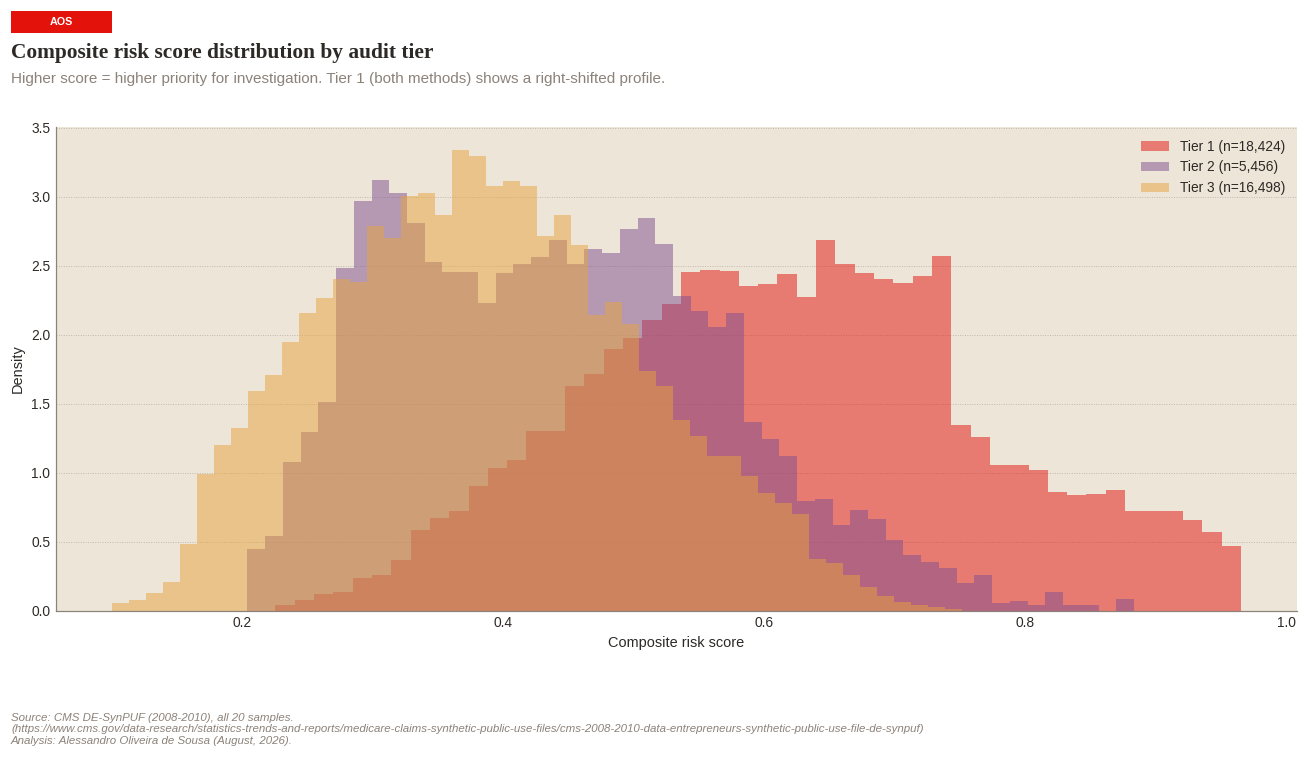

In [35]:
# =============================================================================
# 3.3 - Composite score distribution by tier
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

tier_colors_map = {
    'Tier 1 - High confidence': ECON_RED,
    'Tier 2 - IF multivariate': PLUM,
    'Tier 3 - Z-score statistical': AMBER,
}

for tier, color in tier_colors_map.items():
    subset = flagged[flagged['audit_tier'] == tier]
    if len(subset) > 0:
        ax.hist(subset['composite_score'], bins=50, alpha=0.5, color=color,
                label=f'{tier.split(" - ")[0]} (n={len(subset):,})', density=True)

adjust_axis(ax, xlabel='Composite risk score', ylabel='Density')
ax.legend(fontsize=9)

fig_title(fig,
          title='Composite risk score distribution by audit tier',
          subtitle='Higher score = higher priority for investigation. '
                   'Tier 1 (both methods) shows a right-shifted profile.',
          top=0.9)
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'nb05_composite_distribution.png')
plt.show()


## 4. Case file generation

Each case file is a structured, one-page investigation brief for SIU review. The format mirrors what a Unified Program Integrity Contractor (UPIC) would receive as an initial referral for pre-audit review.

See section `4.3.2.4 - Referrals to the UPIC` at https://www.cms.gov/regulations-and-guidance/guidance/manuals/downloads/pim83c04.pdf.

### Case file contents
- Provider identifiers and derived specialty
- Billing metrics vs. peer group benchmarks
- Z-score profile (which metrics are extreme)
- Isolation Forest anomaly score
- Excess billing estimate and composite risk score
- Recommended investigation actions


In [36]:
# =============================================================================
# 4.1 - Select case file candidates: HIGH priority, Tier 1
# =============================================================================

case_candidates = flagged[
    (flagged['audit_tier'] == 'Tier 1 - High confidence') &
    (flagged['priority'] == 'HIGH')
].sort_values('composite_score', ascending=False)

n_cases = min(20, len(case_candidates))
case_providers = case_candidates.head(n_cases)

print(f"Case file candidates: {len(case_candidates):,} HIGH-priority Tier 1 providers")
print(f"Generating case files for top {n_cases} by composite risk score.")


Case file candidates: 15 HIGH-priority Tier 1 providers
Generating case files for top 15 by composite risk score.


In [37]:
# =============================================================================
# 4.2 - Generate case files (markdown format)
# =============================================================================

z_cols = [c for c in df.columns if c.startswith('z_') and c != 'z_max_abs']

z_label_map = {
    'z_log_avg_paid': 'Avg paid per line',
    'z_lines_per_beneficiary': 'Lines per beneficiary',
    'z_claims_per_beneficiary': 'Claims per beneficiary',
    'z_hcpcs_concentration': 'HCPCS concentration (HHI)',
    'z_pct_high_complexity_em': 'High-complexity E&M %',
    'z_avg_diagnoses_per_claim': 'Avg diagnoses per claim',
    'z_log_total_paid': 'Total paid',
    'z_avg_beneficiary_cc_count': 'Beneficiary case-mix',
}

def generate_case_file(row, rank):
    """Generate a markdown case file for a single provider."""
    npi = row.get('provider_npi', 'Unknown')
    specialty = row.get('derived_specialty', 'Unknown')
    tier = row.get('audit_tier', 'Unknown')
    priority = row.get('priority', 'Unknown')

    lines = [
        f'# Case File: Provider {npi}',
        f'',
        f'**Generated:** {datetime.now().strftime("%Y-%m-%d %H:%M")}  ',
        f'**Project:** Provider Aberrant Billing Pattern Detection (P3)  ',
        f'**Data source:** CMS DE-SynPUF 2008-2010 (synthetic - see limitations below)  ',
        f'**Rank:** {rank} of {n_cases} (by composite risk score)',
        f'',
        f'---',
        f'',
        f'## Provider profile',
        f'',
        f'| Field | Value |',
        f'|---|---|',
        f'| NPI | {npi} |',
        f'| Derived specialty | {specialty} |',
        f'| Audit tier | {tier} |',
        f'| Priority | **{priority}** |',
        f'| Composite risk score | {row.get("composite_score", 0):.3f} (P{row.get("composite_pctl", 0):.0f}) |',
        f'',
        f'## Billing metrics',
        f'',
        f'| Metric | Value |',
        f'|---|---|',
        f'| Total claim lines | {row.get("total_lines", 0):,.0f} |',
        f'| Total paid | ${row.get("total_paid", 0):,.0f} |',
        f'| Avg paid per line | ${row.get("avg_paid_per_line", 0):.2f} |',
        f'| Lines per beneficiary | {row.get("lines_per_beneficiary", 0):.1f} |',
        f'| Claims per beneficiary | {row.get("claims_per_beneficiary", 0):.1f} |',
        f'| HCPCS concentration (HHI) | {row.get("hcpcs_concentration", 0):.4f} |',
        f'| Distinct beneficiaries | {row.get("distinct_beneficiaries", 0):,.0f} |',
        f'',
        f'## Anomaly detection signals',
        f'',
        f'| Signal | Value | Interpretation |',
        f'|---|---|---|',
        f'| Max |z-score| | {row.get("z_max_abs", 0):.2f} | {"Severe" if row.get("z_max_abs", 0) > 3.0 else "Elevated"} |',
        f'| IF anomaly score | {row.get("if_score", 0):.4f} | More negative = more anomalous |',
    ]

    if has_excess:
        lines.append(f'| Excess billing | ${row.get("excess_positive", 0):,.0f} | vs. peer group median |')

    # Z-score breakdown
    active_z = [(c, row.get(c, 0)) for c in z_cols if abs(row.get(c, 0)) > Z_THRESHOLD_PRIMARY]
    if active_z:
        lines.extend([
            f'',
            f'## Z-score profile (metrics above threshold)',
            f'',
            f'| Metric | Z-score | Direction |',
            f'|---|---|---|',
        ])
        for col, val in sorted(active_z, key=lambda x: abs(x[1]), reverse=True):
            label = z_label_map.get(col, col)
            direction = '↑ Above peers' if val > 0 else '↓ Below peers'
            lines.append(f'| {label} | {val:.2f} | {direction} |')

    # Recommended actions
    lines.extend([
        f'',
        f'## Recommended investigation actions',
        f'',
        f'1. **Claims-level review:** Pull all carrier claims for this NPI. Examine HCPCS code distribution, modifier usage, and place-of-service patterns.',
        f'2. **Temporal analysis:** Plot monthly billing volume over the 2008–2010 window. Look for sudden ramps or sustained high-volume periods.',
        f'3. **Beneficiary overlap:** Identify beneficiaries seen by this provider and check for shared-beneficiary patterns with other flagged providers.',
        f'4. **Peer comparison:** Compare this provider\'s billing profile against the top-10 and bottom-10 in their HCPCS-based peer group.',
        f'',
        f'## Limitations',
        f'',
        f'This case file is generated from **CMS DE-SynPUF synthetic data**. The NPI is synthetic, the billing amounts are noise-injected, and the beneficiary linkages are scrambled. This case file demonstrates the format and methodology of an SIU referral - it does not represent a real investigation target.',
        f'',
        f'---',
        f'*{DATA_SOURCE_CITATION.replace(chr(10), " ")}*',
    ])

    return '\n'.join(lines)


# Generate and save
generated_files = []
for rank, (idx, row) in enumerate(case_providers.iterrows(), 1):
    content = generate_case_file(row, rank)
    filename = f'case_{rank:02d}_npi_{int(row["provider_npi"])}.md'
    filepath = CASE_FILES_DIR / filename
    filepath.write_text(content)
    generated_files.append(filepath.name)

print(f"Generated {len(generated_files)} case files in {CASE_FILES_DIR.relative_to(PROJECT_ROOT)}")
for f in generated_files[:5]:
    print(f"  {f}")
if len(generated_files) > 5:
    print(f"  ... and {len(generated_files) - 5} more.")


Generated 15 case files in .
  case_01_npi_9940587011.md
  case_02_npi_6804338533.md
  case_03_npi_4332659805.md
  case_04_npi_6955475791.md
  case_05_npi_8698467005.md
  ... and 10 more.


In [38]:
# =============================================================================
# 4.3 - Preview: first case file
# =============================================================================

from IPython.display import display, Markdown

first_case = CASE_FILES_DIR / generated_files[0]
display(Markdown(first_case.read_text()))


# Case File: Provider 9940587011

**Generated:** 2026-08-26 20:12  
**Project:** Provider Aberrant Billing Pattern Detection (P3)  
**Data source:** CMS DE-SynPUF 2008-2010 (synthetic - see limitations below)  
**Rank:** 1 of 15 (by composite risk score)

---

## Provider profile

| Field | Value |
|---|---|
| NPI | 9940587011 |
| Derived specialty | Evaluation & Management |
| Audit tier | Tier 1 - High confidence |
| Priority | **HIGH** |
| Composite risk score | 0.965 (P100) |

## Billing metrics

| Metric | Value |
|---|---|
| Total claim lines | 72,361 |
| Total paid | $3,258,440 |
| Avg paid per line | $45.03 |
| Lines per beneficiary | 11.9 |
| Claims per beneficiary | 6.3 |
| HCPCS concentration (HHI) | 0.0660 |
| Distinct beneficiaries | 6,070 |

## Anomaly detection signals

| Signal | Value | Interpretation |
|---|---|---|
| Max |z-score| | 23.38 | Severe |
| IF anomaly score | -0.2183 | More negative = more anomalous |
| Excess billing | $50,477 | vs. peer group median |

## Recommended investigation actions

1. **Claims-level review:** Pull all carrier claims for this NPI. Examine HCPCS code distribution, modifier usage, and place-of-service patterns.
2. **Temporal analysis:** Plot monthly billing volume over the 2008–2010 window. Look for sudden ramps or sustained high-volume periods.
3. **Beneficiary overlap:** Identify beneficiaries seen by this provider and check for shared-beneficiary patterns with other flagged providers.
4. **Peer comparison:** Compare this provider's billing profile against the top-10 and bottom-10 in their HCPCS-based peer group.

## Limitations

This case file is generated from **CMS DE-SynPUF synthetic data**. The NPI is synthetic, the billing amounts are noise-injected, and the beneficiary linkages are scrambled. This case file demonstrates the format and methodology of an SIU referral - it does not represent a real investigation target.

---
*Source: CMS DE-SynPUF (2008-2010), all 20 samples. (https://www.cms.gov/data-research/statistics-trends-and-reports/medicare-claims-synthetic-public-use-files/cms-2008-2010-data-entrepreneurs-synthetic-public-use-file-de-synpuf) Analysis: Alessandro Oliveira de Sousa (August, 2026).*

## 5. Investigation priority list - executive summary


In [39]:
# =============================================================================
# 5.1 - Top 30 providers by composite risk score (all priorities)
# =============================================================================

top30 = flagged.nlargest(30, 'composite_score')

display_cols = ['provider_npi', 'derived_specialty', 'audit_tier', 'priority',
                'composite_score', 'composite_pctl']

metric_cols = ['total_paid', 'avg_paid_per_line', 'lines_per_beneficiary',
               'z_max_abs', 'if_score']
if has_excess:
    metric_cols.append('excess_positive')

available = [c for c in display_cols + metric_cols if c in top30.columns]

fmt_dict = {
    'total_paid': '${:,.0f}',
    'avg_paid_per_line': '${:.2f}',
    'lines_per_beneficiary': '{:.1f}',
    'z_max_abs': '{:.2f}',
    'if_score': '{:.4f}',
    'composite_score': '{:.3f}',
    'composite_pctl': '{:.0f}',
}
if has_excess:
    fmt_dict['excess_positive'] = '${:,.0f}'

render_table(
    top30[available].reset_index(drop=True),
    title='Top 30 providers by composite risk score',
    fmt=fmt_dict
)


provider_npi,derived_specialty,audit_tier,priority,composite_score,composite_pctl,total_paid,avg_paid_per_line,lines_per_beneficiary,z_max_abs,if_score,excess_positive
9940587011,Evaluation & Management,Tier 1 - High confidence,HIGH,0.965,100,"$3,258,440",$45.03,11.9,23.38,-0.2183,"$50,477"
6589872281,Evaluation & Management,Tier 1 - High confidence,LOW,0.964,100,"$640,300",$45.49,12.8,25.27,-0.2093,"$16,228"
5005205657,Evaluation & Management,Tier 1 - High confidence,MEDIUM,0.964,100,"$1,616,110",$45.21,9.8,18.24,-0.2190,"$31,480"
2343465738,Evaluation & Management,Tier 1 - High confidence,LOW,0.964,100,"$1,263,540",$45.06,9.1,16.91,-0.2117,"$20,449"
6804338533,Evaluation & Management,Tier 1 - High confidence,HIGH,0.964,100,"$5,874,570",$45.12,9.1,16.78,-0.2067,"$103,066"
7137919052,Evaluation & Management,Tier 1 - High confidence,LOW,0.964,100,"$83,010",$50.04,14.6,30.07,-0.2078,"$9,462"
4624826458,Evaluation & Management,Tier 1 - High confidence,MEDIUM,0.963,100,"$2,711,900",$44.98,8.4,14.98,-0.2104,"$38,945"
652228068,Evaluation & Management,Tier 1 - High confidence,MEDIUM,0.963,100,"$3,991,760",$44.64,8.7,15.86,-0.2062,"$27,791"
2689606218,Evaluation & Management,Tier 1 - High confidence,LOW,0.963,100,"$4,453,230",$44.42,10.0,18.81,-0.2117,"$8,827"
7453437781,Evaluation & Management,Tier 1 - High confidence,LOW,0.963,100,"$314,270",$45.48,12.5,25.14,-0.2102,"$7,931"


## 6. Export


In [40]:
# =============================================================================
# 6.1 - Export flagged providers with composite scores
# =============================================================================

export_cols = [
    'provider_npi', 'derived_specialty', 'audit_tier', 'priority',
    'composite_score', 'composite_pctl',
    'total_lines', 'total_paid', 'avg_paid_per_line',
    'lines_per_beneficiary', 'claims_per_beneficiary',
    'hcpcs_concentration', 'z_max_abs', 'if_score',
]
if has_excess:
    export_cols.append('excess_positive')

available_export = [c for c in export_cols if c in flagged.columns]

export_path = OUTPUT_DIR / 'nb05_flagged_providers_prioritized.csv'
flagged[available_export].to_csv(export_path, index=False)

print(f"Exported: {len(flagged):,} flagged providers × {len(available_export)} columns")
print(f"File: {export_path.name}")
print(f"\nPriority breakdown:")
for p in ['HIGH', 'MEDIUM', 'LOW', 'MONITOR']:
    n = (flagged['priority'] == p).sum()
    print(f"  {p:10s} {n:>6,}")


Exported: 40,378 flagged providers × 15 columns
File: nb05_flagged_providers_prioritized.csv

Priority breakdown:
  HIGH           21
  MEDIUM         27
  LOW        10,047
  MONITOR    30,283


## 7. Methodology limitations & caveats

### 7.1 Synthetic data limitations

DE-SynPUF was designed by CMS for educational and methodological purposes. The synthesis process introduces specific distortions that affect aberrant billing detection:

- **Noise injection:** Continuous variables (payment amounts, utilization counts) have random noise added. The extreme tails, where aberrant billing lives, are the most distorted region.
- **Distribution truncation:** CMS truncated distributions to prevent re-identification. This compresses the very outliers we are trying to detect.
- **Scrambled linkages:** Beneficiary-provider relationships are synthetic. Metrics like `lines_per_beneficiary` and `claims_per_beneficiary` reflect manufactured relationships, not real clinical encounters.
- **Homogeneous tails:** The top 20 Tier 1 providers show suspiciously uniform billing profiles (avg paid ~$44–45, HHI ~0.068). Real Medicare data has far more heterogeneity in the tails.

**What transfers:** The analytical framework (peer-group z-scores → Isolation Forest → two-gate concordance → composite scoring → tiered triage) is production-grade and would work on real claims data with minimal modification.

**What does not transfer:** Specific dollar estimates, provider flag counts, specialty distributions, and the case files themselves.

### 7.2 Multi-stack rationale

This project implements the same analytical pipeline across three technology stacks:

- **Snowflake (SQL):** Dimensional modeling, data quality checks, initial z-score computation with broad specialty peer groups.
- **SAS:** PROC STDIZE + PROC RANK for independent z-score validation, demonstrating cross-technology reproducibility.
- **Python/DuckDB:** HCPCS-level peer groups, Isolation Forest, cross-method validation, composite scoring, and case file generation.

In a production setting, a single stack would be selected based on organizational infrastructure, licensing, and team expertise. The multi-stack approach here demonstrates:

1. Proficiency across the technologies most commonly found in US healthcare FWA operations.
2. The ability to reconcile outputs across independent implementations (Python vs. Snowflake κ = 0.26, reflecting deliberate methodology improvements, not bugs).
3. That the analytical logic is technology-agnostic - the same peer-group z-score concept produces consistent results whether implemented in SQL, SAS, or Python.

### 7.3 Methodological choices

Key decisions and their rationale:

| Decision | Choice | Rationale |
|---|---|---|
| MIN_CLAIMS | 30 | Excludes low-volume providers where z-scores are unreliable |
| Peer grouping | HCPCS-level | More homogeneous than broad specialty; reduces false flags |
| Z-score flagging | Conjunction (≥2 metrics) | Reduces single-metric noise; requires multi-dimensional aberrance |
| IF contamination | 0.05 | Analyst-set, not learned; sensitivity analysis at 0.03–0.15 |
| Composite weights | Equal (30-30-30-10) | No empirical basis for differential weighting without outcome labels |

### 7.4 What a production system would add

- **NPPES taxonomy:** Real provider specialty from NPI registry, replacing HCPCS-derived proxy.
- **Feedback loop:** Historical investigation outcomes to calibrate contamination and composite weights.
- **Temporal modeling:** Month-over-month billing trajectory, not just aggregate metrics.
- **Network analysis:** Shared-beneficiary graphs to detect provider rings.
- **Geographic adjustment:** Regional payment variation (GPCI) normalization.


## 8. Project summary


In [41]:
# =============================================================================
# Final summary
# =============================================================================

total = len(df)
n_flagged = (df['audit_tier'] != 'Unflagged').sum()
n_tier1 = (df['audit_tier'] == 'Tier 1 - High confidence').sum()
n_high = (flagged['priority'] == 'HIGH').sum()

print("=" * 70)
print("Project P3 - Provider Aberrant Billing Pattern Detection")
print("Notebook 05 - Business Impact & Case File Triage")
print("=" * 70)
print()
print(f"  Dataset:                 CMS DE-SynPUF 2008–2010 (synthetic)")
print(f"  Providers analyzed:      {total:,}")
print(f"  Flagged (any method):    {n_flagged:,} ({n_flagged/total*100:.1f}%)")
print(f"  Tier 1 (both methods):   {n_tier1:,} ({n_tier1/total*100:.1f}%)")
print(f"  HIGH priority:           {n_high:,}")
print()
if has_excess:
    total_excess = flagged['excess_positive'].sum()
    tier1_excess = flagged.loc[flagged['audit_tier'] == 'Tier 1 - High confidence', 'excess_positive'].sum()
    high_excess = flagged.loc[flagged['priority'] == 'HIGH', 'excess_positive'].sum()
    print(f"  Total excess (all flagged):  ${total_excess:,.0f}")
    print(f"  Tier 1 excess:               ${tier1_excess:,.0f}")
    print(f"  HIGH priority excess:        ${high_excess:,.0f}")
    print()
print(f"  Case files generated:    {len(generated_files)}")
print(f"  Case files location:     {CASE_FILES_DIR.relative_to(PROJECT_ROOT)}")
print()
print("  Pipeline:")
print("    Snowflake (SQL) → dimensional model, DQ, initial z-scores")
print("    SAS → PROC STDIZE/RANK cross-validation")
print("    Python/DuckDB → HCPCS peer groups, IF, concordance, triage")
print()
print("  ⚠ All dollar figures are from synthetic data.")
print("    The framework transfers; the specific numbers do not.")
print()
print("=" * 70)
print("\n" + DATA_SOURCE_CITATION)


Project P3 - Provider Aberrant Billing Pattern Detection
Notebook 05 - Business Impact & Case File Triage

  Dataset:                 CMS DE-SynPUF 2008–2010 (synthetic)
  Providers analyzed:      477,589
  Flagged (any method):    40,378 (8.5%)
  Tier 1 (both methods):   18,424 (3.9%)
  HIGH priority:           21

  Total excess (all flagged):  $31,615,341
  Tier 1 excess:               $17,040,354
  HIGH priority excess:        $2,674,073

  Case files generated:    15
  Case files location:     .

  Pipeline:
    Snowflake (SQL) → dimensional model, DQ, initial z-scores
    SAS → PROC STDIZE/RANK cross-validation
    Python/DuckDB → HCPCS peer groups, IF, concordance, triage

  ⚠ All dollar figures are from synthetic data.
    The framework transfers; the specific numbers do not.


Source: CMS DE-SynPUF (2008-2010), all 20 samples.
(https://www.cms.gov/data-research/statistics-trends-and-reports/medicare-claims-synthetic-public-use-files/cms-2008-2010-data-entrepreneurs-synthetic-p